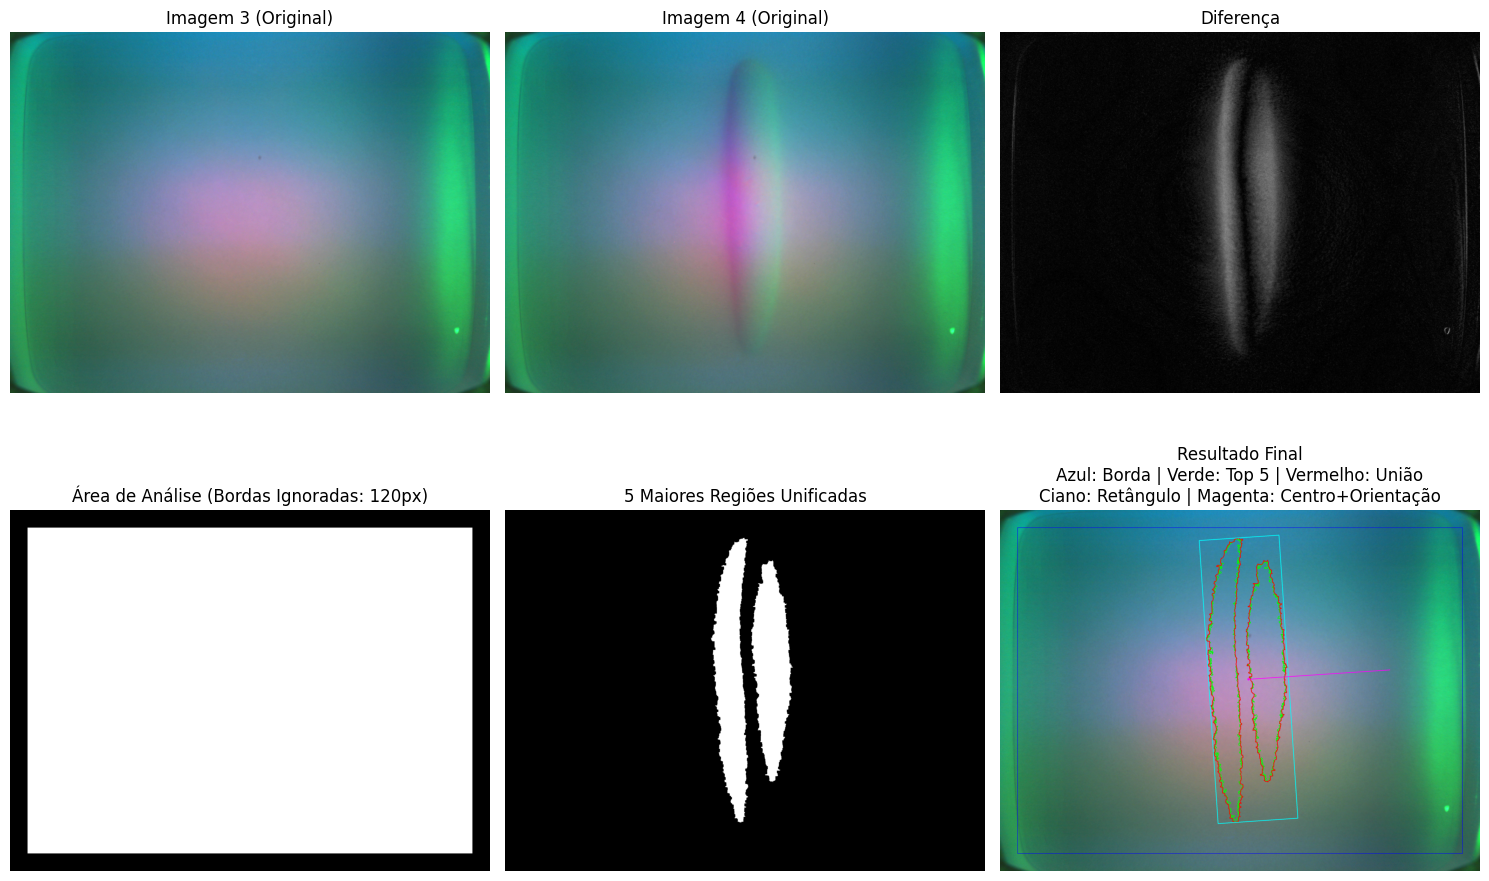

Área de borda ignorada: 120 pixels
Total de contornos detectados: 2
Top 5 maiores regiões selecionadas
Área das 5 maiores regiões: 529146 pixels
Área da região unificada: 566788 pixels

--- Análise do Retângulo ---
Centro do retângulo: (1698.7, 1156.0) pixels
Dimensões: 546.3 x 1936.2 pixels
Ângulo de rotação: -3.81 graus

--- Deslocamento do Centro ---
Centro da imagem: (1640, 1232) pixels
Deslocamento X: 58.7 pixels
Deslocamento Y: -76.0 pixels
Distância do centro: 96.0 pixels


In [25]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Carregar as imagens
img3 = cv2.imread('src/tactile_cameras/examples/my_photo-3.jpg')
img4 = cv2.imread('src/tactile_cameras/examples/my_photo-4.jpg')

# Definir área de borda a ser ignorada
border_size = 120  # Tamanho da borda em pixels a ser ignorada

# Converter para escala de cinza
gray3 = cv2.cvtColor(img3, cv2.COLOR_BGR2GRAY)
gray4 = cv2.cvtColor(img4, cv2.COLOR_BGR2GRAY)

# Calcular a diferença absoluta entre as imagens
diff = cv2.absdiff(gray3, gray4)

# Aplicar threshold para destacar as diferenças significativas
_, thresh = cv2.threshold(diff, 10, 255, cv2.THRESH_BINARY)

# Criar máscara para ignorar área de borda
h, w = thresh.shape
border_mask = np.zeros((h, w), dtype=np.uint8)
border_mask[border_size:h-border_size, border_size:w-border_size] = 255

# Aplicar máscara de borda ao threshold
thresh = cv2.bitwise_and(thresh, border_mask)

# Encontrar contornos da área de contato
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Filtrar contornos por área mínima
valid_contours = [c for c in contours if cv2.contourArea(c) > 500]

# Selecionar as 5 maiores regiões
valid_contours_sorted = sorted(valid_contours, key=cv2.contourArea, reverse=True)
top_5_contours = valid_contours_sorted[:5]

# Criar máscara para unir as 5 maiores regiões
unified_mask = np.zeros_like(thresh)
for contour in top_5_contours:
    cv2.drawContours(unified_mask, [contour], -1, 255, -1)

# Aplicar operação morfológica para unir regiões próximas
kernel_large = np.ones((15,15), np.uint8)
unified_mask = cv2.morphologyEx(unified_mask, cv2.MORPH_CLOSE, kernel_large)

# Encontrar o contorno da região unificada
unified_contours, _ = cv2.findContours(unified_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Criar imagem de resultado
result = img3.copy()

# Desenhar a área de borda ignorada em azul
cv2.rectangle(result, (border_size, border_size), (w-border_size, h-border_size), (255, 0, 0), 2)

contact_area = 0

# Desenhar as 5 maiores regiões originais em verde
for contour in top_5_contours:
    cv2.drawContours(result, [contour], -1, (0, 255, 0), 2)
    contact_area += cv2.contourArea(contour)

# Desenhar o contorno unificado em vermelho
if len(unified_contours) > 0:
    cv2.drawContours(result, unified_contours, -1, (0, 0, 255), 3)
    unified_area = sum([cv2.contourArea(c) for c in unified_contours])
    
    # Calcular retângulo mínimo rotacionado que contém a região unificada
    # Concatenar todos os pontos dos contornos unificados
    all_points = np.vstack(unified_contours)
    
    # Calcular retângulo mínimo orientado
    rect = cv2.minAreaRect(all_points)
    box = cv2.boxPoints(rect)
    box = box.astype(int)
    
    # Extrair informações do retângulo
    center, (width, height), angle = rect
    center_x, center_y = center
    
    # Desenhar o retângulo em ciano
    cv2.drawContours(result, [box], 0, (255, 255, 0), 3)
    
    # Desenhar o ponto central em magenta
    cv2.circle(result, (int(center_x), int(center_y)), 8, (255, 0, 255), -1)
    
    # Desenhar linha indicando a orientação
    angle_rad = np.radians(angle)
    line_length = max(width, height) / 2
    end_x = int(center_x + line_length * np.cos(angle_rad))
    end_y = int(center_y + line_length * np.sin(angle_rad))
    cv2.line(result, (int(center_x), int(center_y)), (end_x, end_y), (255, 0, 255), 3)
    
    # Calcular posição do centro em relação ao centro da imagem
    img_center_x, img_center_y = w // 2, h // 2
    offset_x = center_x - img_center_x
    offset_y = center_y - img_center_y
    distance_from_center = np.sqrt(offset_x**2 + offset_y**2)

# Visualizar resultados
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].imshow(cv2.cvtColor(img3, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title('Imagem 3 (Original)')
axes[0, 0].axis('off')

axes[0, 1].imshow(cv2.cvtColor(img4, cv2.COLOR_BGR2RGB))
axes[0, 1].set_title('Imagem 4 (Original)')
axes[0, 1].axis('off')

axes[0, 2].imshow(diff, cmap='gray')
axes[0, 2].set_title('Diferença')
axes[0, 2].axis('off')

axes[1, 0].imshow(border_mask, cmap='gray')
axes[1, 0].set_title(f'Área de Análise (Bordas Ignoradas: {border_size}px)')
axes[1, 0].axis('off')

axes[1, 1].imshow(unified_mask, cmap='gray')
axes[1, 1].set_title('5 Maiores Regiões Unificadas')
axes[1, 1].axis('off')

axes[1, 2].imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
axes[1, 2].set_title(f'Resultado Final\nAzul: Borda | Verde: Top 5 | Vermelho: União\nCiano: Retângulo | Magenta: Centro+Orientação')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

print(f"Área de borda ignorada: {border_size} pixels")
print(f"Total de contornos detectados: {len(valid_contours)}")
print(f"Top 5 maiores regiões selecionadas")
print(f"Área das 5 maiores regiões: {contact_area:.0f} pixels")
if len(unified_contours) > 0:
    print(f"Área da região unificada: {unified_area:.0f} pixels")
    print(f"\n--- Análise do Retângulo ---")
    print(f"Centro do retângulo: ({center_x:.1f}, {center_y:.1f}) pixels")
    print(f"Dimensões: {width:.1f} x {height:.1f} pixels")
    print(f"Ângulo de rotação: {angle:.2f} graus")
    print(f"\n--- Deslocamento do Centro ---")
    print(f"Centro da imagem: ({img_center_x}, {img_center_y}) pixels")
    print(f"Deslocamento X: {offset_x:.1f} pixels")
    print(f"Deslocamento Y: {offset_y:.1f} pixels")
    print(f"Distância do centro: {distance_from_center:.1f} pixels")